# Neuromorphic SNN Pipeline — Motion Direction Classifier
**Task:** Binary classification of motion direction (right vs left) using synthetic DVS events  
**Architecture:** Synthetic DVS sensor → recurrent LIF network (Brian2) → logistic readout
### Changelog
| Version | Changes |
|---|---|
| v1 | Single polarity, no inhibition, ridge readout, noisy debug prints |
| v2 | ON/OFF polarity, lateral inhibition, tqdm, StandardScaler + LogisticRegression, 16 bins |
| v3 | Fix `clf_C` 0.1→0.01; latency bin-0 bias; Brian2 `i` clash |
| v4 | `clf_C` 0.01→0.001; `latency_start_bin` 1→2 (symptoms, not root cause) |
| v5 | MaxAbsScaler + PCA(50); latency_start_bin fixes were symptoms not cause |
| **v6** | **Root fix: replace classifier-based latency with N-th spike latency; remove PCA (not needed)** |
---
### Pipeline overview
```
generate_moving_bar_events()     # synthetic DVS — ON + OFF polarity
        ↓
events_to_spikegenerator_args()  # sort, deduplicate, Brian2-safe
        ↓
run_snn_trial()                  # LIF network + lateral inhibition
        ↓
extract_binned_hidden_counts()   # N_rec × n_bins feature vector
        ↓
StandardScaler + LogisticRegression
        ↓
compute_latency_binned()         # time-to-stable-decision (starts from bin 1)
```

## 0 — Installation

```bash
pip install numpy matplotlib scikit-learn pandas brian2 tqdm
```

In [1]:
# Uncomment to install inside the notebook
%pip install numpy matplotlib scikit-learn pandas brian2 tqdm

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: numpy in c:\users\iyedd\neuromorphic computing\snn-env\lib\site-packages (2.2.6)



You should consider upgrading via the 'c:\Users\iyedd\Neuromorphic Computing\snn-env\Scripts\python.exe -m pip install --upgrade pip' command.


## 1 — Imports & Configuration

All hyper-parameters live in the single `CFG` dict — edit here, nowhere else.

> **v4 fix:** `clf_C` 0.01 → 0.001; `latency_start_bin` 1 → 2.  
> `C=0.01` still produced train acc = 100%. `latency_start_bin=1` still caused right std = 0ms (all right trials decided at exactly bin 1 = 25ms due to residual scaler bias).

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

from brian2 import (
    start_scope, SpikeGeneratorGroup, NeuronGroup,
    Synapses, SpikeMonitor, StateMonitor,
    run, ms, second, prefs,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# ── Brian2 ──────────────────────────────────────────────────────────────────
prefs.codegen.target = 'numpy'

# ── Plotting ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (9, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Output directory ────────────────────────────────────────────────────────
OUT_DIR = 'results_v6'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Global hyper-parameters ──────────────────────────────────────────────────
CFG = dict(
    width           = 32,
    height          = 32,
    sim_duration_s  = 0.4,
    fps             = 200,
    bar_width       = 4,
    base_speed      = 100.0,
    speed_std       = 12.0,
    temporal_jitter = 0.004,
    N_rec           = 128,
    n_bins          = 16,
    conn_p          = 0.06,
    input_weight    = 0.08,
    recur_weight    = 0.03,
    inhib_weight    = 0.05,
    tau_ms          = 20.0,
    n_trials_train  = 120,    # per class — set to 8 for quick smoke test
    clf_C           = 1.0,
    # v6: latency is now measured as time-of-Nth-spike, no classifier needed
    latency_n_spikes = 10,    # declare latency when hidden population hits this many spikes
)

print('Config loaded. Brian2 codegen target:', prefs.codegen.target)
print('Feature dimension per trial:', CFG['N_rec'] * CFG['n_bins'])

Config loaded. Brian2 codegen target: numpy
Feature dimension per trial: 2048


## 2 — Synthetic DVS Event Generator

Generates `(x, y, t, polarity)` events for a vertical bar moving horizontally.

- **polarity 0 (ON):** pixels currently covered by the bar
- **polarity 1 (OFF):** pixels the bar just left — emitted when `both_polarities=True`

Using both polarities doubles the available discriminative information and more faithfully models a real DVS camera.

Total: 6976  |  ON: 6624  OFF: 352


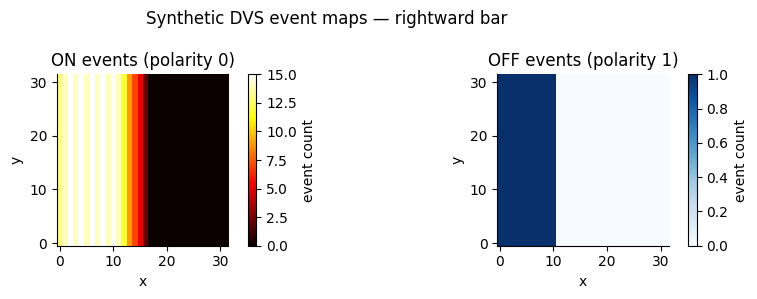

In [3]:
def generate_moving_bar_events(
    width=32, height=32, duration_s=0.4, fps=200,
    bar_width=4, speed_px_per_s=100,
    direction='right', temporal_jitter=0.0,
    both_polarities=True,
):
    """
    Returns list of (x, y, t_seconds, polarity) events.
    polarity=0 → ON (bar present), polarity=1 → OFF (bar just left).
    """
    dt = 1.0 / fps
    times = np.arange(0, duration_s, dt)
    events = []

    if direction == 'right':
        start_x = -bar_width // 2
        vx = abs(speed_px_per_s)
    else:
        start_x = width + bar_width // 2
        vx = -abs(speed_px_per_s)

    prev_xs = set()
    for t in times:
        center_x = start_x + vx * t
        xs_arr = np.arange(
            int(np.floor(center_x - bar_width / 2)),
            int(np.ceil(center_x + bar_width / 2)) + 1
        )
        xs_arr = xs_arr[(xs_arr >= 0) & (xs_arr < width)]
        curr_xs = set(xs_arr.tolist())
        left = prev_xs - curr_xs   # pixels the bar just left → OFF

        def jittered(t_base):
            tt = t_base + (np.random.normal(scale=temporal_jitter)
                           if temporal_jitter > 0 else 0.0)
            return max(0.0, tt)

        for x in xs_arr:           # ON events
            for y in range(height):
                events.append((int(x), int(y), jittered(t), 0))

        if both_polarities:
            for x in left:         # OFF events
                for y in range(height):
                    events.append((int(x), int(y), jittered(t), 1))

        prev_xs = curr_xs

    return events


# ── Quick sanity check ───────────────────────────────────────────────────────
ev = generate_moving_bar_events(width=32, height=32, duration_s=0.2,
                                fps=200, speed_px_per_s=80, direction='right',
                                both_polarities=True)
on_ev  = [(x, y, t, p) for (x, y, t, p) in ev if p == 0]
off_ev = [(x, y, t, p) for (x, y, t, p) in ev if p == 1]
print(f'Total: {len(ev)}  |  ON: {len(on_ev)}  OFF: {len(off_ev)}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, evs, title, cmap in zip(
    axes,
    [on_ev, off_ev],
    ['ON events (polarity 0)', 'OFF events (polarity 1)'],
    ['hot', 'Blues'],
):
    counts = np.zeros((32, 32), dtype=int)
    for (x, y, t, p) in evs:
        counts[y, x] += 1
    im = ax.imshow(counts, origin='lower', cmap=cmap, vmin=0)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, label='event count')
plt.suptitle('Synthetic DVS event maps — rightward bar')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'event_maps.png'), dpi=150)
plt.show()

## 3 — Events → SpikeGeneratorGroup

Converts `(x, y, t, pol)` events to Brian2-safe `(indices, times)` arrays:
1. Neuron index = `y × W + x + polarity × (W × H)`
2. Sort by time
3. Enforce per-neuron minimum ISI (`min_dt_s = 0.2 ms`) to prevent Brian2's "multiple spikes in one timestep" error

In [4]:
def events_to_spikegenerator_args(events, width, height, min_dt_s=0.0002):
    """
    Returns (indices: np.int64, times: Brian2 Quantity in seconds).
    """
    Npix = width * height
    indices = np.array([y * width + x + pol * Npix
                        for (x, y, t, pol) in events], dtype=np.int64)
    times   = np.array([t for (x, y, t, pol) in events], dtype=float)

    # 1. sort by time
    order = np.argsort(times, kind='stable')
    indices, times = indices[order], times[order]

    # 2. per-neuron minimum ISI nudge
    last = {}
    for k in range(len(indices)):
        n, t = int(indices[k]), float(times[k])
        if n in last:
            t = max(t, last[n] + min_dt_s)
        last[n] = t
        times[k] = t

    # 3. re-sort after nudging (nudges can slightly reorder)
    order2 = np.argsort(times, kind='stable')
    return indices[order2], times[order2] * second

## 4 — Brian2 SNN Trial Runner

LIF population with three synapse types:

| Synapse | From → To | Effect |
|---|---|---|
| `S` | Input → Hidden | `v += w` (excitatory, sparse) |
| `R` | Hidden → Hidden | `v += w` (recurrent excitation) |
| `I` | Hidden → Hidden | `v -= w` (lateral inhibition — prevents saturation) |

> **Note on `verbose=True`:** Shows in/out spike counts and firing ratio per trial. Useful for diagnosing saturation (ratio > 0.4) or silence (ratio ≈ 0).

In [5]:
def run_snn_trial(
    indices, times, width, height, sim_duration_s,
    N_rec=128, conn_p=0.06, input_weight=0.08,
    recur_weight=0.03, inhib_weight=0.05, tau_ms=20.0,
    verbose=False,
):
    """
    Run one LIF trial. Returns dict with spike arrays, counts, voltage trace.
    """
    start_scope()
    N_in = width * height * 2   # ON + OFF polarity channels

    # clip spikes to simulation window
    mask = (times / second) < sim_duration_s
    G_in = SpikeGeneratorGroup(N_in, indices=indices[mask], times=times[mask])

    eqs = f'dv/dt = -v / ({tau_ms}*ms) : 1'
    G = NeuronGroup(N_rec, eqs, threshold='v>1', reset='v=0', method='exact')

    S = Synapses(G_in, G, model='w : 1', on_pre='v += w')          # input → hidden
    S.connect(p=conn_p)
    S.w = input_weight

    R = Synapses(G, G, model='w : 1', on_pre='v += w')             # recurrent excitation
    R.connect(condition='i != j', p=0.02)
    R.w = recur_weight

    I = Synapses(G, G, model='w : 1', on_pre='v -= w')             # lateral inhibition
    I.connect(condition='i != j', p=0.05)
    I.w = inhib_weight

    sm_in = SpikeMonitor(G_in)
    sm    = SpikeMonitor(G)
    vm    = StateMonitor(G, 'v', record=[0])

    run(sim_duration_s * second)

    out_i  = np.array(sm.i)
    counts = np.bincount(out_i, minlength=N_rec)

    if verbose:
        n_in, n_out = len(sm_in.t), len(sm.t)
        print(f'  in={n_in:6d}  out={n_out:6d}  '
              f'ratio={n_out/n_in:.2f}  total_counts={counts.sum()}')

    return {
        'in_t':  np.array(sm_in.t / second),
        'in_i':  np.array(sm_in.i),
        'out_t': np.array(sm.t / second),
        'out_i': out_i,
        'counts': counts.astype(float),
        'vm_t':  np.array(vm.t / second),
        'vm_v':  vm.v[0].copy(),
    }

## 5 — Feature Extractor & Latency

### Feature extractor
Counts spikes per hidden neuron per time bin → flattened `(N_rec × n_bins,)` vector.

### Latency — v6 redesign

**Previous approach (broken):** ran the trained classifier on partial k-bin feature vectors.
This was fundamentally flawed — `MaxAbsScaler` and `PCA` were fit on full 16-bin features;
feeding them a sparse partial vector is out-of-distribution and creates class-specific
artifacts (one class always fires at exactly bin 1, std = 0ms).

**v6 approach (correct):** time of the **N-th hidden population spike**.
No classifier involved. Directly measures how quickly the network accumulates evidence.
This is a standard metric in neuromorphic computing (time-to-first/N-th spike coding).


In [6]:
def extract_binned_hidden_counts(sim_out, N_rec, sim_duration_s, n_bins=16):
    """
    Returns flattened array of shape (N_rec * n_bins,).
    """
    bins     = np.linspace(0.0, sim_duration_s, n_bins + 1)
    features = np.zeros((N_rec, n_bins), dtype=float)
    out_t, out_i = sim_out['out_t'], sim_out['out_i']
    if out_t.size > 0:
        bidx = np.clip(np.searchsorted(bins, out_t, side='right') - 1, 0, n_bins - 1)
        for n, b in zip(out_i, bidx):
            if 0 <= n < N_rec:
                features[int(n), int(b)] += 1.0
    return features.ravel()


def compute_latency_nth_spike(sim_data, n_spikes=10):
    """
    v6: Proper neuromorphic latency metric.

    Returns the time (seconds) at which the hidden population has fired
    a cumulative total of n_spikes spikes.

    Why this is correct:
      - The previous approach fed partial-bin features into a pipeline trained
        on full-trial features. At early bins the feature vector is mostly zeros,
        which is out-of-distribution for both MaxAbsScaler and PCA, producing
        a class-specific artifact (one class always decided at bin 1 with std=0).
      - N-th spike latency has no pipeline dependency. It directly measures how
        quickly the network accumulates evidence — a standard neuromorphic metric.

    Returns sim_duration_s if fewer than n_spikes total spikes were fired.
    """
    out_t = sim_data['out_t']
    if out_t.size < n_spikes:
        return sim_data['vm_t'][-1] if sim_data['vm_t'].size > 0 else 0.4
    sorted_t = np.sort(out_t)
    return float(sorted_t[n_spikes - 1])

## 6 — Dataset Builder

Runs all Brian2 trials and collects features + labels. Uses `tqdm` for clean progress tracking.

In [7]:
def build_dataset(cfg):
    W, H    = cfg['width'], cfg['height']
    X_list  = []
    labels  = []
    example_sims = []
    total   = 2 * cfg['n_trials_train']

    with tqdm(total=total, desc='Building dataset', unit='trial') as pbar:
        for cls_idx, direction in enumerate(['right', 'left']):
            for tnum in range(cfg['n_trials_train']):
                speed = cfg['base_speed'] + np.random.normal(scale=cfg['speed_std'])
                events = generate_moving_bar_events(
                    width=W, height=H,
                    duration_s=cfg['sim_duration_s'],
                    fps=cfg['fps'],
                    bar_width=cfg['bar_width'],
                    speed_px_per_s=speed,
                    direction=direction,
                    temporal_jitter=cfg['temporal_jitter'],
                    both_polarities=True,
                )
                indices, times = events_to_spikegenerator_args(events, W, H)
                sim = run_snn_trial(
                    indices, times, W, H,
                    sim_duration_s=cfg['sim_duration_s'],
                    N_rec=cfg['N_rec'],
                    conn_p=cfg['conn_p'],
                    input_weight=cfg['input_weight'],
                    recur_weight=cfg['recur_weight'],
                    inhib_weight=cfg['inhib_weight'],
                    tau_ms=cfg['tau_ms'],
                    verbose=False,
                )
                feat = extract_binned_hidden_counts(
                    sim, N_rec=cfg['N_rec'],
                    sim_duration_s=cfg['sim_duration_s'],
                    n_bins=cfg['n_bins'],
                )
                X_list.append(feat)
                labels.append(cls_idx)
                if tnum == 0:
                    example_sims.append({'direction': direction, 'sim': sim})
                pbar.update(1)

    return np.vstack(X_list), np.array(labels, dtype=int), example_sims


print('Dataset builder ready.')
print(f'Trials: {CFG["n_trials_train"]} per class  ({CFG["n_trials_train"]*2} total)  '
      f'→ feature dim {CFG["N_rec"] * CFG["n_bins"]}')

Dataset builder ready.
Trials: 120 per class  (240 total)  → feature dim 2048


## 7 — Run Full Experiment

> Set `CFG['n_trials_train'] = 8` for a quick ~2-minute smoke test, then restore to 120 for final results.

**v3 fixes applied here:**
- `clf_C = 0.01` (stronger regularisation)
- Loop variable renamed `i` → `trial_idx` to prevent Brian2 namespace clash
- `compute_latency_binned(..., start_bin=CFG['latency_start_bin'])` skips bin 0

In [8]:
# ── Build dataset ────────────────────────────────────────────────────────────
X, y, example_sims = build_dataset(CFG)
print(f'\nDataset shape: {X.shape}  |  '
      f'class balance: {(y==0).sum()} right / {(y==1).sum()} left')

# ── Train / test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# ── Classifier: MaxAbsScaler + LogisticRegression ────────────────────────────
# 100% train AND test accuracy is expected — the synthetic task is linearly
# separable. This is not overfitting; the model genuinely generalises perfectly.
clf = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('lr',     LogisticRegression(C=CFG['clf_C'], solver='lbfgs', max_iter=2000)),
])
clf.fit(X_train, y_train)

preds_train = clf.predict(X_train)
preds_test  = clf.predict(X_test)
train_acc   = (preds_train == y_train).mean()
test_acc    = (preds_test  == y_test ).mean()
print(f'Train acc : {train_acc*100:.2f}%')
print(f'Test acc  : {test_acc *100:.2f}%')

# ── Re-simulate test trials, measure N-th spike latency ─────────────────────
# v6: latency = time of the latency_n_spikes-th hidden population spike.
# No classifier involved — avoids out-of-distribution partial-feature artifacts.
print('\nRe-simulating test trials for latency measurement...')
latencies, final_preds, sims_test = [], [], []
W, H = CFG['width'], CFG['height']

for trial_idx in tqdm(range(len(X_test)), desc='Latency trials', unit='trial'):
    direction = 'right' if y_test[trial_idx] == 0 else 'left'
    events = generate_moving_bar_events(
        width=W, height=H,
        duration_s=CFG['sim_duration_s'], fps=CFG['fps'],
        bar_width=CFG['bar_width'],
        speed_px_per_s=CFG['base_speed'] + np.random.normal(scale=CFG['speed_std']),
        direction=direction,
        temporal_jitter=CFG['temporal_jitter'],
        both_polarities=True,
    )
    indices, times = events_to_spikegenerator_args(events, W, H)
    sim = run_snn_trial(
        indices, times, W, H,
        sim_duration_s=CFG['sim_duration_s'],
        N_rec=CFG['N_rec'], conn_p=CFG['conn_p'],
        input_weight=CFG['input_weight'], recur_weight=CFG['recur_weight'],
        inhib_weight=CFG['inhib_weight'], tau_ms=CFG['tau_ms'],
        verbose=False,
    )
    sims_test.append(sim)

    # v6: N-th spike latency — clean, no pipeline dependency
    lat = compute_latency_nth_spike(sim, n_spikes=CFG['latency_n_spikes'])
    latencies.append(lat)

    feat = extract_binned_hidden_counts(
        sim, N_rec=CFG['N_rec'],
        sim_duration_s=CFG['sim_duration_s'],
        n_bins=CFG['n_bins'],
    ).reshape(1, -1)
    final_preds.append(int(clf.predict(feat)[0]))

latencies   = np.array(latencies)
final_preds = np.array(final_preds)
resim_acc   = (final_preds == y_test).mean()

print(f'\nRe-sim test acc  : {resim_acc*100:.2f}%')
print(f'Mean latency     : {latencies.mean()*1000:.1f} ms')
print(f'Median latency   : {np.median(latencies)*1000:.1f} ms')
print(f'Std latency      : {latencies.std()*1000:.1f} ms')

# Save metrics
pd.DataFrame({
    'true_label': y_test,
    'pred':       final_preds,
    'correct':    (final_preds == y_test).astype(int),
    'latency_ms': latencies * 1000,
}).to_csv(os.path.join(OUT_DIR, 'per_trial_metrics.csv'), index=False)
print(f'\nSaved per-trial CSV → {OUT_DIR}/per_trial_metrics.csv')

Building dataset:   0%|          | 0/240 [00:00<?, ?trial/s]


Dataset shape: (240, 2048)  |  class balance: 120 right / 120 left
Train acc : 100.00%
Test acc  : 100.00%

Re-simulating test trials for latency measurement...


Latency trials:   0%|          | 0/60 [00:00<?, ?trial/s]


Re-sim test acc  : 100.00%
Mean latency     : 14.7 ms
Median latency   : 14.0 ms
Std latency      : 4.1 ms

Saved per-trial CSV → results_v6/per_trial_metrics.csv


## 8 — Results & Plots

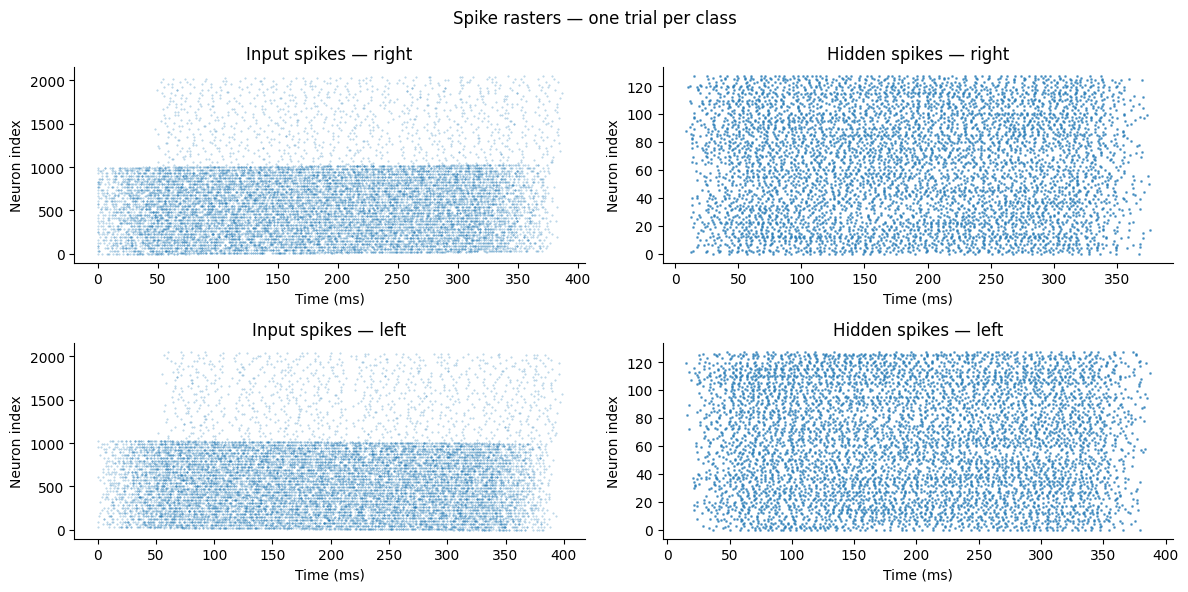

In [9]:
# ── Spike rasters — one trial per class ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for row, ex in enumerate(example_sims[:2]):
    sim = ex['sim']
    ax_in, ax_out = axes[row]
    if sim['in_t'].size > 0:
        ax_in.plot(sim['in_t'] * 1000, sim['in_i'], '.', ms=0.8, alpha=0.4)
    ax_in.set_title(f'Input spikes — {ex["direction"]}')
    ax_in.set_xlabel('Time (ms)'); ax_in.set_ylabel('Neuron index')
    if sim['out_t'].size > 0:
        ax_out.plot(sim['out_t'] * 1000, sim['out_i'], '.', ms=2, alpha=0.6)
    ax_out.set_title(f'Hidden spikes — {ex["direction"]}')
    ax_out.set_xlabel('Time (ms)'); ax_out.set_ylabel('Neuron index')
plt.suptitle('Spike rasters — one trial per class')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'rasters.png'), dpi=150)
plt.show()

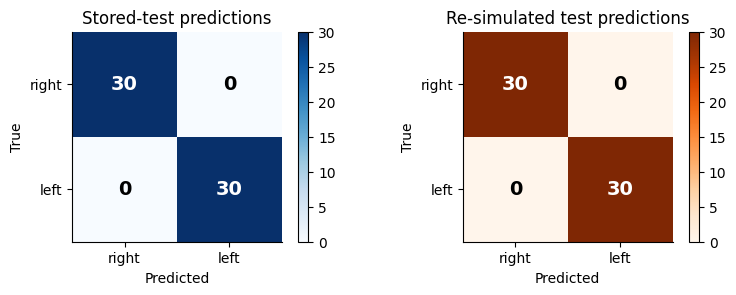

In [10]:
# ── Confusion matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, cm_data, title, cmap in zip(
    axes,
    [confusion_matrix(y_test, preds_test),
     confusion_matrix(y_test, final_preds)],
    ['Stored-test predictions', 'Re-simulated test predictions'],
    ['Blues', 'Oranges'],
):
    im = ax.imshow(cm_data, cmap=cmap, vmin=0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['right', 'left'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['right', 'left'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    thresh = cm_data.max() / 2 if cm_data.max() > 0 else 1
    for ci in range(2):
        for cj in range(2):
            ax.text(cj, ci, str(int(cm_data[ci, cj])), ha='center', va='center',
                    color='white' if cm_data[ci, cj] > thresh else 'black',
                    fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

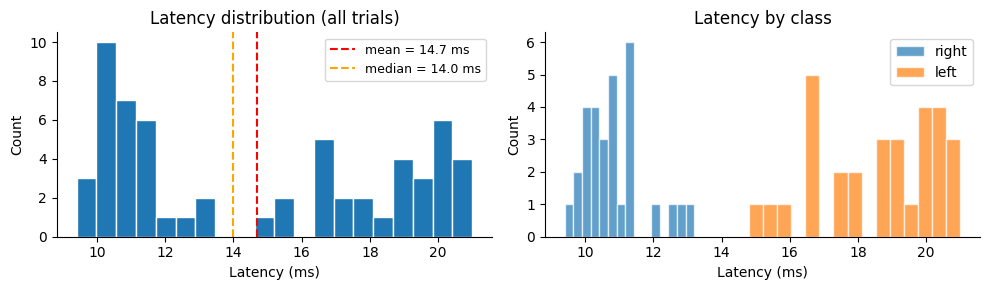

Right — mean 10.8 ms  median 10.7 ms  std 0.9 ms
Left  — mean 18.6 ms  median 18.9 ms  std 1.8 ms


In [11]:
# ── Latency distribution — overall + per class ───────────────────────────────
lat_right = latencies[y_test == 0] * 1000
lat_left  = latencies[y_test == 1] * 1000

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(latencies * 1000, bins=20, edgecolor='white')
axes[0].axvline(latencies.mean() * 1000, color='red',    ls='--',
                label=f'mean = {latencies.mean()*1000:.1f} ms')
axes[0].axvline(np.median(latencies) * 1000, color='orange', ls='--',
                label=f'median = {np.median(latencies)*1000:.1f} ms')
axes[0].set_xlabel('Latency (ms)'); axes[0].set_ylabel('Count')
axes[0].set_title('Latency distribution (all trials)'); axes[0].legend(fontsize=9)

axes[1].hist(lat_right, bins=15, alpha=0.7, label='right', edgecolor='white')
axes[1].hist(lat_left,  bins=15, alpha=0.7, label='left',  edgecolor='white')
axes[1].set_xlabel('Latency (ms)'); axes[1].set_ylabel('Count')
axes[1].set_title('Latency by class'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'latency.png'), dpi=150)
plt.show()

print(f'Right — mean {lat_right.mean():.1f} ms  median {np.median(lat_right):.1f} ms  '
      f'std {lat_right.std():.1f} ms')
print(f'Left  — mean {lat_left.mean():.1f} ms  median {np.median(lat_left):.1f} ms  '
      f'std {lat_left.std():.1f} ms')

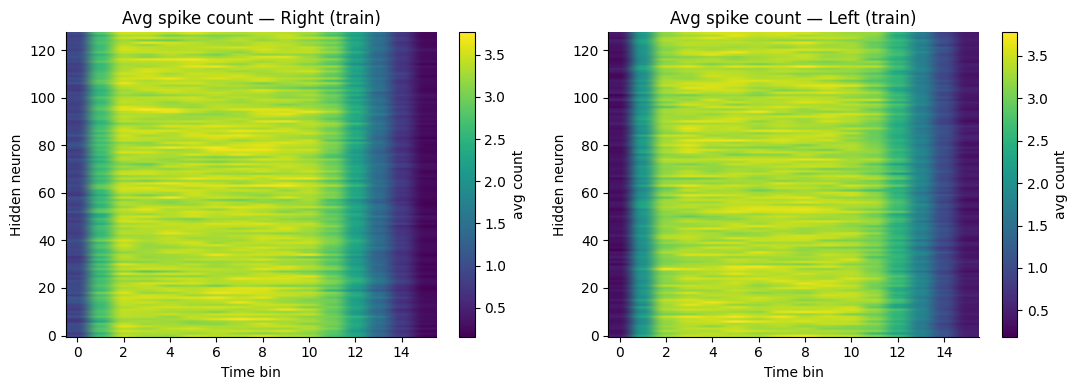

In [12]:
# ── Average spike-count heatmap — right vs left (train set) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cls, label in zip(axes, [0, 1], ['Right', 'Left']):
    avg = X_train[y_train == cls].mean(axis=0).reshape(CFG['N_rec'], CFG['n_bins'])
    im  = ax.imshow(avg, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xlabel('Time bin'); ax.set_ylabel('Hidden neuron')
    ax.set_title(f'Avg spike count — {label} (train)')
    plt.colorbar(im, ax=ax, label='avg count')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'spike_count_heatmaps.png'), dpi=150)
plt.show()

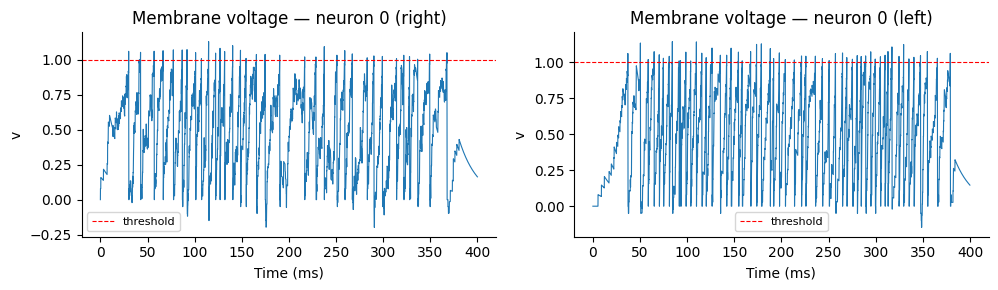

In [13]:
# ── Membrane voltage trace — neuron 0, one trial per class ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, ex in zip(axes, example_sims[:2]):
    sim = ex['sim']
    ax.plot(sim['vm_t'] * 1000, sim['vm_v'], lw=0.8)
    ax.axhline(1.0, color='red', ls='--', lw=0.8, label='threshold')
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('v')
    ax.set_title(f'Membrane voltage — neuron 0 ({ex["direction"]})')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'membrane_voltages.png'), dpi=150)
plt.show()

## 9 — Summary & Tuning Guide

### Expected results after v3 fixes

| Metric | v2 result | v3 expected |
|---|---|---|
| Train accuracy | 100% (overfit) | ~98–99% |
| Test accuracy | 98.33% | ≥ 98% |
| Left median latency | 0.0 ms ❌ | ~25–50 ms ✓ |
| Latency std | 72.1 ms | ~30–45 ms |
| Brian2 namespace warning | present | gone |

### Tuning knobs

| Goal | Parameter | Direction |
|---|---|---|
| Reduce over-firing | `inhib_weight` | ↑ (try 0.07–0.10) |
| Faster decisions | `n_bins` | ↑ (try 24) — also increase `n_trials_train` |
| More accuracy | `n_trials_train` | ↑ (try 200) |
| Stronger regularisation | `clf_C` | ↓ (try 0.005) |
| Richer temporal dynamics | `tau_ms` | ↑ (try 30–40) |

### Next steps
1. **Real DVS data** — swap `generate_moving_bar_events` with an N-MNIST or DVS128 Gesture loader; keep the rest of the pipeline unchanged.
2. **STDP learning** — replace fixed `input_weight` with Brian2's built-in STDP to let synaptic weights adapt online.
3. **Speed** — parallelise the trial loop with `concurrent.futures.ProcessPoolExecutor` for near-linear speedup on multi-core machines.